In [62]:
from tqdm import tqdm
import pandas as pd
from contour_characteristics import load_json_data
from plotting_functions import plot_data, get_gsd, get_curve

coco_json = '/projects/OLIVINE/data/output/PARTICLE/Amodal/oryx/model_B/southLow_all_07x_run1_36fps_0.2/coco_formatted.json'
data = load_json_data(coco_json)


In [63]:
df = pd.DataFrame(data)

In [64]:
df = df[df['touch_edge'] == False]

In [65]:
# # save GSD curve
sand_name = 'olivine'
df_gsd = get_curve(df, './', key='ellip_volume')
df_gsd.to_csv(f'./save_annotations_df_{sand_name}.csv')

In [66]:
import numpy as np
# Function to find rows closest to target values
def get_closest_rows(df, column, target_values):
    closest_rows = []
    for target in target_values:
        # Calculate the absolute difference
        df['abs_diff'] = np.abs(df[column] - target)
        # Find the row with the minimum difference
        closest_row = df.loc[df['abs_diff'].idxmin()]
        closest_rows.append(closest_row)
    # Drop the temporary 'abs_diff' column
    df.drop(columns=['abs_diff'], inplace=True)
    return pd.DataFrame(closest_rows)

target_values = [10, 16, 20, 25, 30, 40, 50, 60, 71, 76, 80, 84, 90]
# Get rows closest to target values in column 'A'
result = get_closest_rows(df_gsd, column='percentage_passing', target_values=target_values)

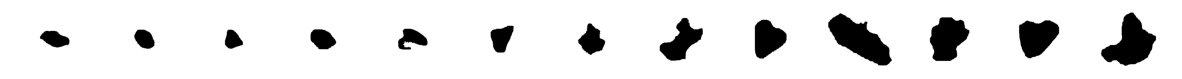

In [69]:
import cv2
import matplotlib.pyplot as plt

particle_image_height = 200
particle_image_width = 300

# Function to center contour points in the image
def center_contour(contour_points, target_width, target_height):
    # Convert contour points to a NumPy array
    contour = np.array(contour_points, dtype=np.int32)
    
    # Reshape flat lists into (N, 2) format if necessary
    if contour.ndim == 1:
        contour = contour.reshape(-1, 2)
    
    # Get bounding box of the contour
    x_min, y_min = contour.min(axis=0)
    x_max, y_max = contour.max(axis=0)
    
    # Calculate the center of the bounding box
    contour_center_x = (x_min + x_max) // 2
    contour_center_y = (y_min + y_max) // 2
    
    # Calculate the center of the blank image
    image_center_x = target_width // 2
    image_center_y = target_height // 2
    
    # Calculate the offset to center the contour
    offset_x = image_center_x - contour_center_x
    offset_y = image_center_y - contour_center_y
    
    # Translate the contour points to center them
    contour[:, 0] += offset_x
    contour[:, 1] += offset_y
    
    # Ensure the contour fits within the target dimensions
    if contour[:, 0].min() < 0 or contour[:, 0].max() >= target_width or \
       contour[:, 1].min() < 0 or contour[:, 1].max() >= target_height:
        raise ValueError("Contour exceeds target dimensions after centering. Consider increasing dimensions.")
    
    return contour

# Function to create a filled image for a single particle
def create_filled_image(contour_points, image_height, image_width):
    # Create a blank image
    blank_image = np.zeros((image_height, image_width), dtype=np.uint8)
    
    # Normalize and translate contour points
    normalized_contour = center_contour(contour_points, image_width, image_height)
    
    # Fill the contour on the blank image
    cv2.fillPoly(blank_image, [normalized_contour], color=255)

    inverted_img = cv2.bitwise_not(blank_image)
    
    return inverted_img

# List to store individual particle images
particle_images = []

# Iterate through the segmentation column in the DataFrame
for contour_points in result['segmentation']:
    sorted_lists = sorted(contour_points, key=len, reverse=True)
    contour_points = sorted_lists[0]
    
    filled_image = create_filled_image(contour_points, particle_image_height, particle_image_width)
    particle_images.append(filled_image)

# Combine all particle images horizontally
final_image = np.hstack(particle_images)

# Display the final image
plt.figure(figsize=(15, 5))
plt.imshow(final_image, cmap='gray')
plt.axis('off')
plt.show()
